# Simulation on Orthogonal Estimation

We compare the performance of the naive and orthogonal methods in a computational experiment where
$p=n=100$, $\beta_j = 1/j^2$, $(\gamma_{DW})_j = 1/j^2$ and $$Y = 1 \cdot D + \beta' W + \epsilon_Y$$

where $W \sim N(0,I)$, $\epsilon_Y \sim N(0,1)$, and $$D = \gamma'_{DW} W + \tilde{D}$$ where $\tilde{D} \sim N(0,1)/4$.

The true treatment effect here is 1. From the plots produced in this notebook (estimate minus ground truth), we show that the naive single-selection estimator is heavily biased (lack of Neyman orthogonality in its estimation strategy), while the orthogonal estimator based on partialling out, is approximately unbiased and Gaussian.

In [ ]:
# # As before, we import clone hdmpy to use rlasso functions in python
# !pip install multiprocess
# !pip install pyreadr
# !git clone https://github.com/maxhuppertz/hdmpy.git

In [1]:
import seaborn as sns
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import warnings
warnings.simplefilter('ignore')

import sys
sys.path.insert(1, "./hdmpy")
import hdmpy

In [2]:
# Initialize constants
B = 10000  # Number of iterations
n = 100  # Sample size
p = 100  # Number of features

# Sim Parameters
mean = 0
sd = 1


def exp(it):
    np.random.seed(it)
    # Generate parameters:
    gamma = (1 / (np.arange(1, p + 1) ** 2)).reshape(p, 1)
    beta = (1 / (np.arange(1, p + 1) ** 2)).reshape(p, 1)

    # Generate covariates / random data
    X = np.random.normal(mean, sd, n * p).reshape(n, p)
    D = (X @ gamma) + np.random.normal(mean, sd, n).reshape(n, 1) / 4

    # Generate Y using DGP
    Y = D + (X @ beta) + np.random.normal(mean, sd, n).reshape(n, 1)

    # Single selection method using rlasso
    r_lasso_estimation = hdmpy.rlasso(np.concatenate((D, X), axis=1), Y, post=True)
    coef_array = r_lasso_estimation.est['coefficients'].iloc[2:, :].to_numpy()
    SX_IDs = np.where(coef_array != 0)[0]

    # Check if any X coefficients are selected
    if sum(SX_IDs) == 0:
        # If no X coefficients are selected, regress Y on D only
        Naive = sm.OLS(Y, sm.add_constant(D)).fit().params[1]
    else:
        # If X coefficients are selected, regress Y on selected X and D
        X_D = np.concatenate((D, X[:, SX_IDs]), axis=1)
        Naive = sm.OLS(Y, sm.add_constant(X_D)).fit().params[1]

    # Double Lasso Partialling Out
    fitY = hdmpy.rlasso(X, Y, post=True)
    resY = fitY.est['residuals']

    fitD = hdmpy.rlasso(X, D, post=True)
    resD = fitD.est['residuals']

    Orthogonal = sm.OLS(resY, sm.add_constant(resD)).fit().params[1]

    return Naive, Orthogonal


results = Parallel(n_jobs=-1, verbose=3)(delayed(exp)(it) for it in range(B))

Naive, Orthogonal = zip(*results)
Naive, Orthogonal = np.array(Naive), np.array(Orthogonal)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done 124 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done 444 tasks      | elapsed:    6.0s
[Parallel(n_jobs=-1)]: Done 892 tasks      | elapsed:   10.6s
[Parallel(n_jobs=-1)]: Done 1468 tasks      | elapsed:   16.4s
[Parallel(n_jobs=-1)]: Done 2172 tasks      | elapsed:   23.9s
[Parallel(n_jobs=-1)]: Done 3004 tasks      | elapsed:   32.5s
[Parallel(n_jobs=-1)]: Done 3964 tasks      | elapsed:   42.1s
[Parallel(n_jobs=-1)]: Done 5052 tasks      | elapsed:   53.8s
[Parallel(n_jobs=-1)]: Done 6268 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 7612 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 9084 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:  1.8min finished


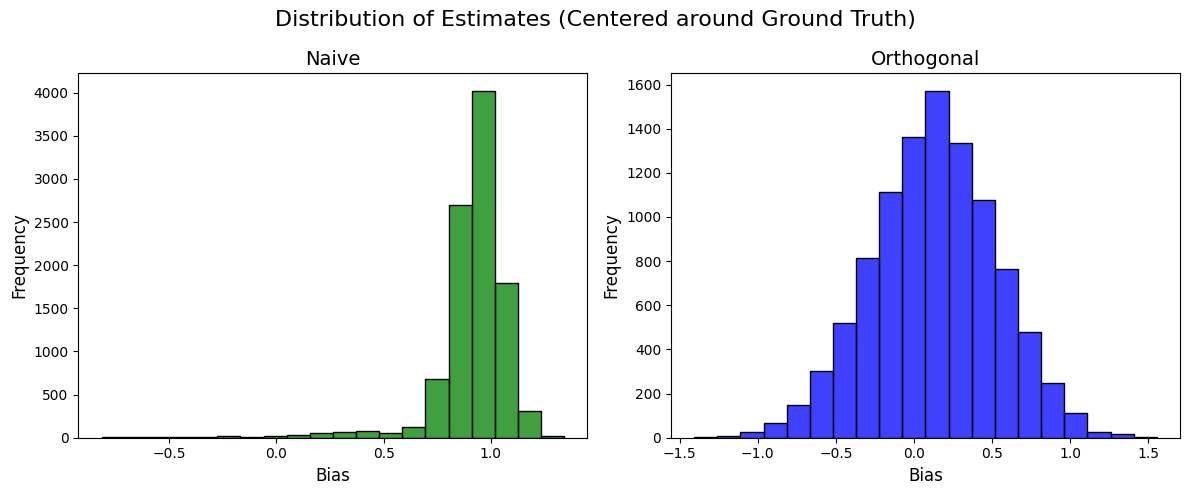

In [3]:
# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot a histogram for the 'Naive' estimates vector
sns.histplot(Naive - 1, bins=20, kde=False, color='green', ax=axes[0])
axes[1].set_title('Orthogonal', fontsize=14)
axes[1].set_xlabel('Bias', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

# Plot a histogram for the 'Orthogonal' estimates vector
sns.histplot(Orthogonal - 1, bins=20, kde=False, color='blue', ax=axes[1])
axes[0].set_title('Naive', fontsize=14)
axes[0].set_xlabel('Bias', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# Add a title to the entire figure
fig.suptitle('Distribution of Estimates (Centered around Ground Truth)', fontsize=16)

# Display the histograms side by side
plt.tight_layout()
plt.show()

As we can see from the above bias plots (estimates minus the ground truth effect of 1), the double lasso procedure concentrates around zero whereas the naive estimator does not.


**Double Lasso Explanation**

- **Step 1 — First-stage selection for Y:** Use a lasso of `Y` on `X` to find controls that predict the outcome.
- **Step 2 — First-stage selection for D:** Use a lasso of `D` on `X` to find controls that predict treatment.
- **Step 3 — Partial out:** Regress `Y` on the selected `X` (or use residuals from the first-stage fit) to obtain `resY`; regress `D` on the selected `X` to obtain `resD`. These residuals remove the variation in `Y` and `D` explained by `X`.
- **Step 4 — Final estimation:** Regress `resY` on `resD` (often with a constant). The slope is the orthogonal estimate of the effect.

Intuition: by removing the part of `Y` and `D` explained by `X`, the final regression isolates variation in `D` that is (approximately) orthogonal to `X`, reducing bias from model selection and ensuring Neyman orthogonality.

In [22]:
# B smaller for quicker runs
B_exp = 2000
n = 100
p = 100
mean = 0
sd = 1

def make_cov(cov_type='identity', rho=0.5):
    if cov_type == 'identity':
        return np.eye(p)
    if cov_type == 'toeplitz':
        idx = np.arange(p)
        return rho ** np.abs(np.subtract.outer(idx, idx))
    if cov_type == 'block':
        cov = np.eye(p) * (1 - rho)
        block_size = 10
        for i in range(0, p, block_size):
            j = slice(i, min(i + block_size, p))
            cov[np.ix_(range(i, min(i+block_size,p)), range(i, min(i+block_size,p)))] += rho
        return cov
    return np.eye(p)

def make_coef(coef_type='decay2'):
    if coef_type == 'decay2':
        return (1 / (np.arange(1, p + 1) ** 2)).reshape(p, 1)
    if coef_type == 'decay1':
        return (1 / (np.arange(1, p + 1))).reshape(p, 1)
    if coef_type == 'sparse':
        v = np.zeros((p, 1))
        v[:5] = 1.0
        return v
    if coef_type == 'random':
        return np.random.normal(0, 1, p).reshape(p, 1)
    return (1 / (np.arange(1, p + 1) ** 2)).reshape(p, 1)

def exp_variant(it, beta_type='decay2', gamma_type='decay2', cov_type='identity'):
    np.random.seed(it)
    cov = make_cov(cov_type)
    mean_vec = np.zeros(p)
    X = np.random.multivariate_normal(mean_vec, cov, size=n)
    beta = make_coef(beta_type)
    gamma = make_coef(gamma_type)
    D = (X @ gamma) + np.random.normal(mean, sd, n).reshape(n, 1) / 4
    Y = D + (X @ beta) + np.random.normal(mean, sd, n).reshape(n, 1)

    # Naive single-selection
    r_lasso_estimation = hdmpy.rlasso(np.concatenate((D, X), axis=1), Y, post=True)
    coef_array = r_lasso_estimation.est['coefficients'].iloc[2:, :].to_numpy()
    SX_IDs = np.where(coef_array != 0)[0]
    if sum(SX_IDs) == 0:
        Naive = sm.OLS(Y, sm.add_constant(D)).fit().params[1]
    else:
        X_D = np.concatenate((D, X[:, SX_IDs]), axis=1)
        Naive = sm.OLS(Y, sm.add_constant(X_D)).fit().params[1]

    # Orthogonal double lasso
    fitY = hdmpy.rlasso(X, Y, post=True)
    resY = fitY.est['residuals']
    fitD = hdmpy.rlasso(X, D, post=True)
    resD = fitD.est['residuals']
    Orthogonal = sm.OLS(resY, sm.add_constant(resD)).fit().params[1]
    return float(Naive), float(Orthogonal)

# Experiments to run: list of (beta_type, gamma_type, cov_type) tuples
experiments = [
    ('decay2', 'decay2', 'identity'),
    ('decay1', 'decay1', 'identity'),
    ('random', 'random', 'identity'),
    ('decay2', 'decay2', 'toeplitz'),
    ('sparse', 'sparse', 'toeplitz'),
    ('decay2', 'sparse', 'block'),
]

results_exp = {}
for (btype, gtype, ctype) in experiments:
    key = f'{btype}_{gtype}_{ctype}'
    print('Running', key)
    res = Parallel(n_jobs=-1, verbose=3)(delayed(exp_variant)(it, btype, gtype, ctype) for it in range(B_exp))
    Naive_v, Orth_v = zip(*res)
    results_exp[key] = { 'Naive': np.array(Naive_v), 'Orthogonal': np.array(Orth_v) }

# Save results_exp to workspace variable for inspection
results_exp


Running decay2_decay2_identity


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done 504 tasks      | elapsed:    5.3s
[Parallel(n_jobs=-1)]: Done 952 tasks      | elapsed:    9.9s
[Parallel(n_jobs=-1)]: Done 1528 tasks      | elapsed:   15.8s
[Parallel(n_jobs=-1)]: Done 1977 out of 2000 | elapsed:   20.4s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done 2000 out of 2000 | elapsed:   20.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


Running decay1_decay1_identity


[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 296 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 936 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done 1832 tasks      | elapsed:    9.0s
[Parallel(n_jobs=-1)]: Done 2000 out of 2000 | elapsed:    9.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.1s


Running random_random_identity


...

Running sparse_sparse_toeplitz


[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 504 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 952 tasks      | elapsed:    6.7s
[Parallel(n_jobs=-1)]: Done 1528 tasks      | elapsed:   10.6s
[Parallel(n_jobs=-1)]: Done 2000 out of 2000 | elapsed:   13.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.1s


Running decay2_sparse_block


[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done 504 tasks      | elapsed:    6.6s
[Parallel(n_jobs=-1)]: Done 952 tasks      | elapsed:   12.7s
[Parallel(n_jobs=-1)]: Done 1528 tasks      | elapsed:   20.4s
[Parallel(n_jobs=-1)]: Done 2000 out of 2000 | elapsed:   26.5s finished


{'decay2_decay2_identity': {'Naive': array([2.03120615, 1.77709009, 1.96533732, ..., 1.95650894, 2.0502019 ,
         1.84784659], shape=(2000,)),
  'Orthogonal': array([1.00389533, 1.30308452, 0.66140568, ..., 1.13001389, 0.95843022,
         0.00406786], shape=(2000,))},
 'decay1_decay1_identity': {'Naive': array([2.03705519, 1.87735335, 1.97216814, ..., 1.97334875, 2.11474738,
         1.89840041], shape=(2000,)),
  'Orthogonal': array([1.76765619, 2.08042407, 1.54181723, ..., 1.45511611, 1.99215367,
         1.33234749], shape=(2000,))},
 'random_random_identity': {'Naive': array([1.03851513, 0.95687273, 0.68291457, ..., 0.95473977, 1.00210152,
         0.84740433], shape=(2000,)),
  'Orthogonal': array([0.85908138, 0.60751467, 0.68929361, ..., 0.93913593, 0.97672621,
         0.60880478], shape=(2000,))},
 'decay2_decay2_toeplitz': {'Naive': array([1.42662289, 1.96540714, 0.47786788, ..., 1.75375694, 1.22725529,
         1.95610711], shape=(2000,)),
  'Orthogonal': array([1.297857

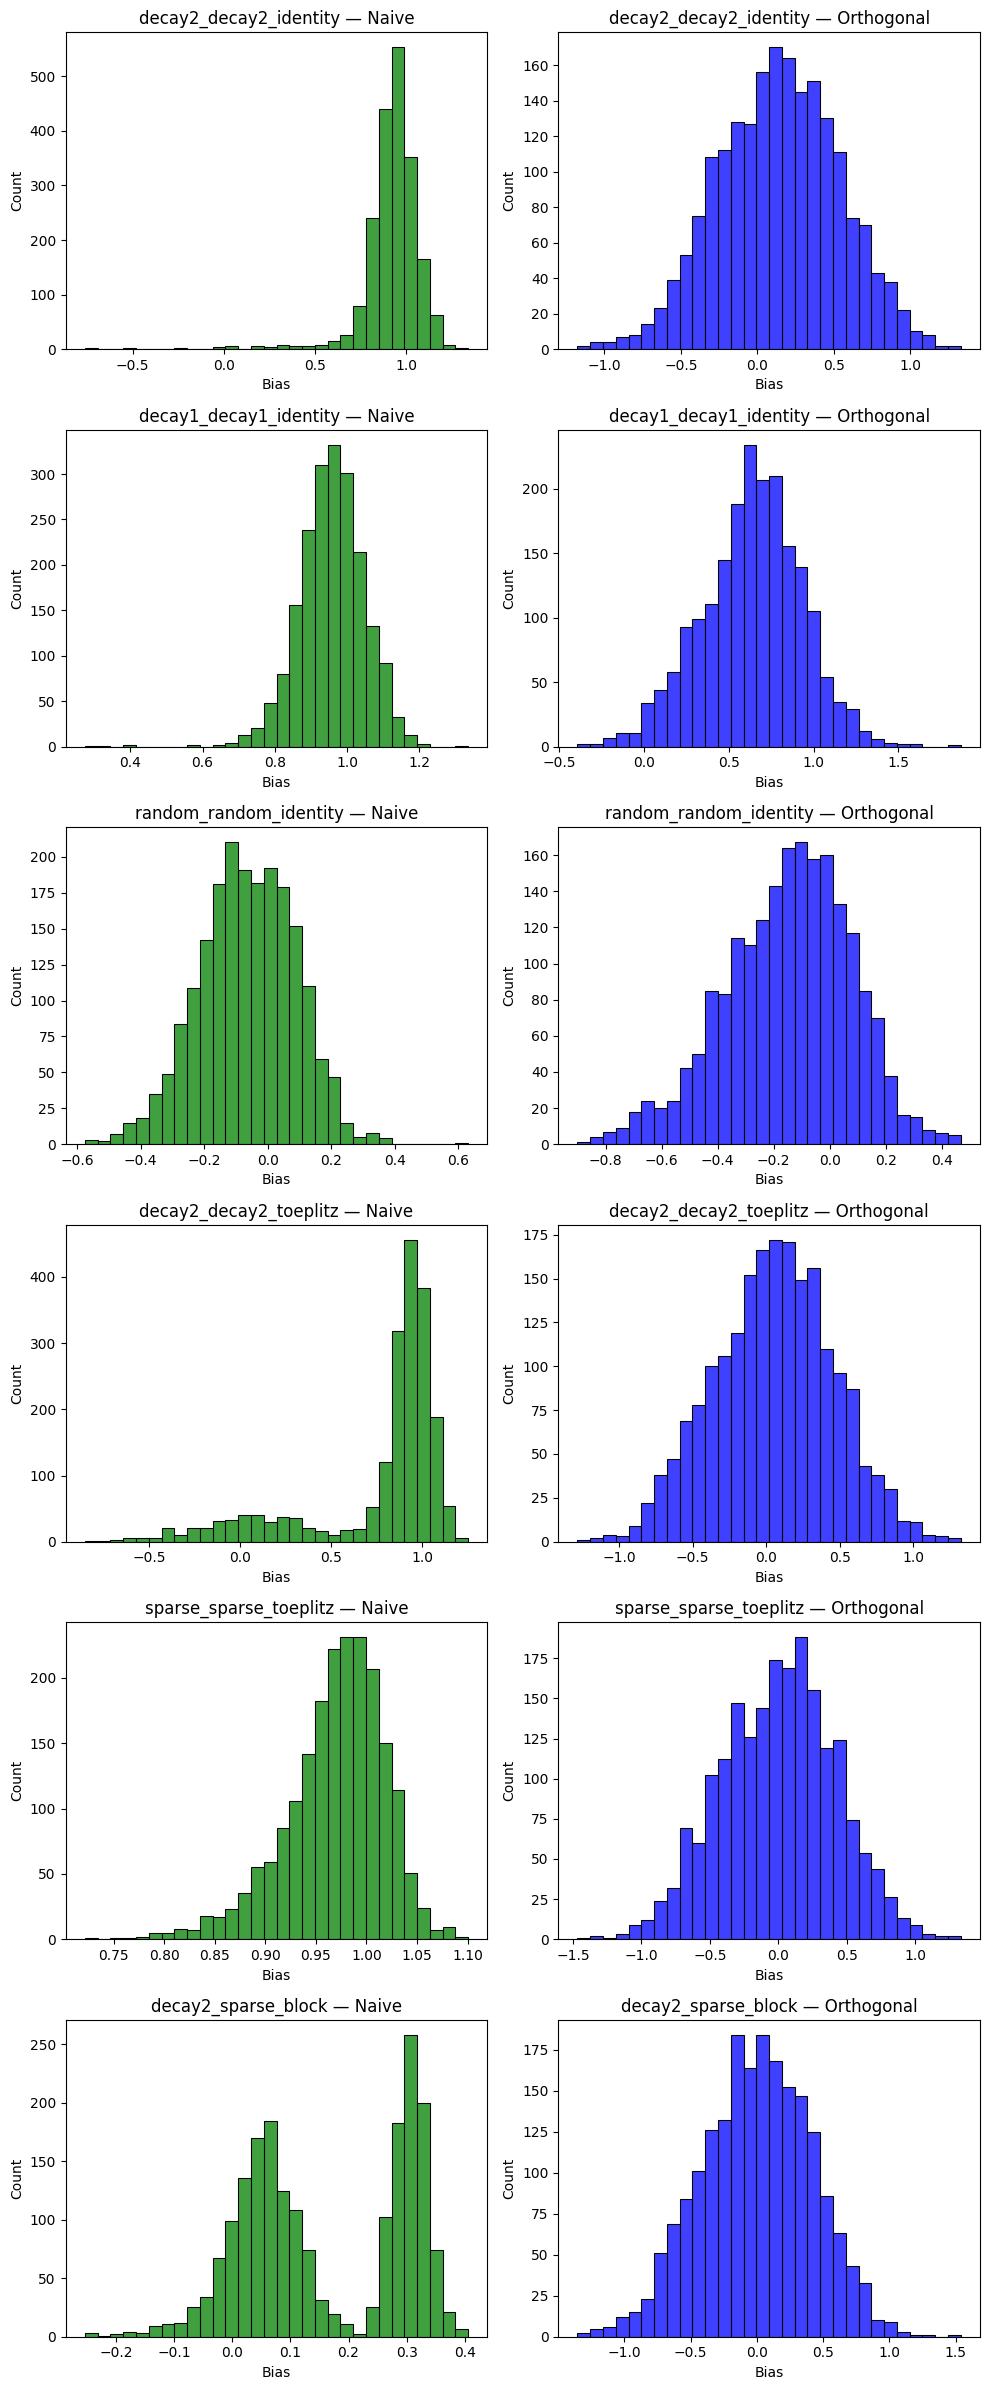

In [23]:
# Plot experiment comparisons (bias = estimate - 1)
fig, axs = plt.subplots(len(results_exp), 2, figsize=(10, 4 * len(results_exp)))
for i, (k, v) in enumerate(results_exp.items()):
    sns.histplot(v['Naive'] - 1, bins=30, kde=False, color='green', ax=axs[i, 0])
    axs[i, 0].set_title(k + ' — Naive')
    axs[i, 0].set_xlabel('Bias')
    sns.histplot(v['Orthogonal'] - 1, bins=30, kde=False, color='blue', ax=axs[i, 1])
    axs[i, 1].set_title(k + ' — Orthogonal')
    axs[i, 1].set_xlabel('Bias')
plt.tight_layout()
plt.savefig("orthogonal_exp.png")
plt.show()

In [24]:
# Summary statistics for each experiment: mean bias and sd (estimate - truth)
import pandas as pd
summary_rows = []
for k, v in results_exp.items():
    na_mean = (v['Naive'] - 1).mean()
    na_sd = (v['Naive'] - 1).std()
    or_mean = (v['Orthogonal'] - 1).mean()
    or_sd = (v['Orthogonal'] - 1).std()
    summary_rows.append({'experiment': k, 'naive_mean_bias': na_mean, 'naive_sd': na_sd, 'orth_mean_bias': or_mean, 'orth_sd': or_sd})
summary_df = pd.DataFrame(summary_rows).set_index('experiment')
print(summary_df.round(4))
summary_df


                        naive_mean_bias  naive_sd  orth_mean_bias  orth_sd
experiment                                                                
decay2_decay2_identity           0.9198    0.1754          0.1402   0.3969
decay1_decay1_identity           0.9563    0.0916          0.6354   0.2965
random_random_identity          -0.0633    0.1513         -0.1497   0.2249
decay2_decay2_toeplitz           0.7646    0.3904          0.0525   0.4056
sparse_sparse_toeplitz           0.9695    0.0494         -0.0020   0.4181
decay2_sparse_block              0.1604    0.1386         -0.0007   0.4204


,naive_mean_bias,naive_sd,orth_mean_bias,orth_sd
experiment,,,,
decay2_decay2_identity,0.919751,0.175446,0.140226,0.396948
decay1_decay1_identity,0.956332,0.091621,0.635371,0.296509
random_random_identity,-0.063312,0.151281,-0.149746,0.224931
decay2_decay2_toeplitz,0.764627,0.390424,0.052481,0.405606
sparse_sparse_toeplitz,0.969485,0.049427,-0.001999,0.418075
decay2_sparse_block,0.160393,0.138645,-0.000699,0.420389
